# Mini-Project : When ML Fails
## Notebook 01 — Exploration & Modèle de référence

**Dataset** : Online Shoppers Purchasing Intention (UCI 468)
**Tâche** : Classification binaire — prédire si une session web mène à un achat
**Famille de modèle** : Gradient Boosting (non-linéaire, ensemble d'arbres)
**Failure mode investigué** : Overfitting & Generalization Gap (Section 5.2 du sujet)

### Objectif de ce notebook

Ce notebook établit la **référence expérimentale** du projet :
1. Chargement et exploration du dataset (EDA)
2. Caractérisation de la classe imbalance et de l'effet temporel (variable `Month`)
3. Entraînement d'un Gradient Boosting Classifier comme modèle de référence
4. Mesure des symptômes de défaillance (performance globale, par sous-groupe, courbes d'apprentissage, corrélations)

Les métriques et figures produites ici servent de **baseline** au notebook 02, qui mettra en œuvre l'expérience contrôlée et la correction.

**Reproductibilité** : `random_state = 42` partout. Le notebook est entièrement réexécutable.

## 1. Configuration de l'environnement

Imports des librairies utilisées (sklearn pour le modèle et les métriques, pandas/numpy pour la manipulation des données, matplotlib/seaborn pour les visualisations). Fixation du `RANDOM_STATE` pour garantir la reproductibilité de tous les résultats.

In [1]:
# ── CELLULE 1 : Imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, recall_score, precision_score
)
from sklearn.ensemble import GradientBoostingClassifier
import warnings
warnings.filterwarnings("ignore")
 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
 
print("Imports OK")

Imports OK


## 2. Chargement et inspection initiale du dataset

Le dataset Online Shoppers contient **12 330 sessions** web décrites par **17 features** mêlant variables comportementales continues (temps passé sur chaque type de page, valeurs commerciales, taux de rebond) et catégorielles (mois, type de visiteur, navigateur, région). La variable cible binaire `Revenue` indique si la session s'est terminée par une transaction.

Cette inspection vérifie l'intégrité du fichier (shape, types, valeurs manquantes) avant tout pré-traitement.


In [2]:
# ── CELLULE 2 : Chargement des données ──────────────────────────────
df = pd.read_csv("data/online_shoppers_intention.csv")

print(f"Shape : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")

Shape : (12330, 18)

Colonnes : ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Types :
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

Valeurs manquantes :
A

## 3. Distribution de la variable cible — Class imbalance

Premier diagnostic critique : la répartition des deux classes. Si la classe minoritaire (achat) est très sous-représentée, l'accuracy globale devient trompeuse et il faudra privilégier des métriques sensibles à l'imbalance (F1, recall, AUC).


Distribution Revenue :
Revenue
False    10422
True      1908
Name: count, dtype: int64

Taux de conversion : 15.5%


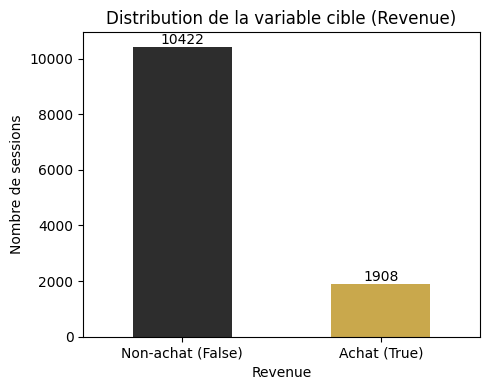

→ CLASS IMBALANCE visible : ~84% non-achat / ~16% achat


In [3]:
# ── CELLULE 3 : Distribution de la target ───────────────────────────────────
target_counts = df["Revenue"].value_counts()
print(f"Distribution Revenue :\n{target_counts}")
print(f"\nTaux de conversion : {target_counts[True] / len(df) * 100:.1f}%")
 
fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", color=["#2d2d2d", "#C9A84C"], edgecolor="none", ax=ax)
ax.set_title("Distribution de la variable cible (Revenue)", fontsize=12)
ax.set_xticklabels(["Non-achat (False)", "Achat (True)"], rotation=0)
ax.set_ylabel("Nombre de sessions")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("report/fig01_target_distribution.png", dpi=150)
plt.show()
print("→ CLASS IMBALANCE visible : ~84% non-achat / ~16% achat")

## 4. Effet temporel — distribution par mois

La feature `Month` est suspectée d'introduire une **dépendance temporelle** dans les données : le taux de conversion en novembre (Black Friday) est attendu plus élevé que sur les autres mois. Cette analyse mesure l'ampleur de cet effet et permettra plus tard de juger si le modèle l'utilise comme **shortcut** ou comme un signal réellement informatif.

Deux visualisations :
- **Volume de sessions par mois** : révèle la concentration temporelle de la collecte
- **Taux de conversion par mois** : montre l'amplitude de la variation saisonnière

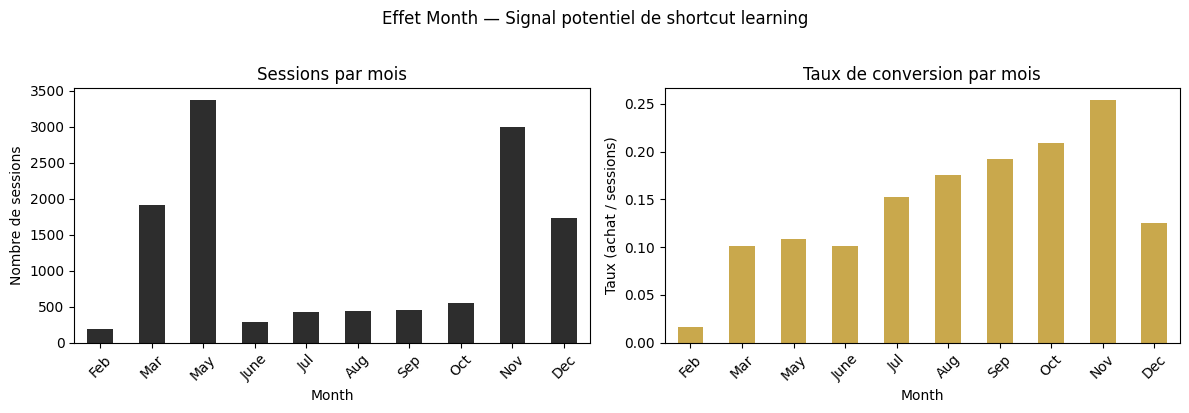


Taux de conversion par mois :
       sessions  achats      taux
Month                            
Feb         184       3  0.016304
Mar        1907     192  0.100682
May        3364     365  0.108502
June        288      29  0.100694
Jul         432      66  0.152778
Aug         433      76  0.175520
Sep         448      86  0.191964
Oct         549     115  0.209472
Nov        2998     760  0.253502
Dec        1727     216  0.125072

→ Novembre : pic d'achats (Black Friday). Signal fort mais potentiellement spurieux.


In [4]:
# ── CELLULE 4 : Distribution par mois ───────────────────────────────────────
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
 
month_conversion = (
    df.groupby("Month")["Revenue"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "achats", "count": "sessions"})
)
month_conversion["taux"] = month_conversion["achats"] / month_conversion["sessions"]
month_conversion = month_conversion.reindex([m for m in month_order if m in month_conversion.index])
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Volume par mois
month_conversion["sessions"].plot(kind="bar", ax=axes[0], color="#2d2d2d", edgecolor="none")
axes[0].set_title("Sessions par mois")
axes[0].set_ylabel("Nombre de sessions")
axes[0].tick_params(axis="x", rotation=45)
 
# Taux de conversion par mois
month_conversion["taux"].plot(kind="bar", ax=axes[1], color="#C9A84C", edgecolor="none")
axes[1].set_title("Taux de conversion par mois")
axes[1].set_ylabel("Taux (achat / sessions)")
axes[1].tick_params(axis="x", rotation=45)
 
plt.suptitle("Effet Month — Signal potentiel de shortcut learning", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("report/fig02_month_effect.png", dpi=150)
plt.show()
 
print("\nTaux de conversion par mois :")
print(month_conversion[["sessions", "achats", "taux"]].to_string())
print("\n→ Novembre : pic d'achats (Black Friday). Signal fort mais potentiellement spurieux.")

## 4.5. Statistiques descriptives des features numériques

Avant de modéliser, on inspecte les **distributions empiriques** des variables continues : moyenne, écart-type, quantiles, valeurs extrêmes. Ces statistiques révèlent :

- l'**échelle** très hétérogène des features (durées en secondes vs taux entre 0 et 1) — peu gênant pour un GBM, mais indispensable à connaître pour interpréter les coefficients d'autres modèles ;
- la présence d'**asymétries fortes** (longue queue à droite) typiques des données de navigation web : la majorité des sessions sont courtes, une minorité est extrêmement longue ;
- des **valeurs nulles fréquentes** sur `Informational`, `Administrative`, `PageValues` — signal que beaucoup de sessions ne visitent qu'un seul type de page.

In [5]:
# ── CELLULE 4.5 : Statistiques descriptives des features numériques ─────────
numeric_cols = df.select_dtypes(include=[np.number, "float64", "int64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Revenue"]

desc = df[numeric_cols].describe().T
desc["skew"] = df[numeric_cols].skew()
desc["pct_zero"] = (df[numeric_cols] == 0).mean()

print("Statistiques descriptives (features numériques) :")
print(desc[["mean", "std", "min", "50%", "max", "skew", "pct_zero"]].round(2).to_string())

print("\n→ Les colonnes 'skew' > 3 et 'pct_zero' > 0.5 marquent les features très asymétriques")
print("  et fortement zéro-gonflées : caractéristiques des données de clickstream web.")

Statistiques descriptives (features numériques) :
                            mean      std  min     50%       max  skew  pct_zero
Administrative              2.32     3.32  0.0    1.00     27.00  1.96      0.47
Administrative_Duration    80.82   176.78  0.0    7.50   3398.75  5.62      0.48
Informational               0.50     1.27  0.0    0.00     24.00  4.04      0.79
Informational_Duration     34.47   140.75  0.0    0.00   2549.38  7.58      0.80
ProductRelated             31.73    44.48  0.0   18.00    705.00  4.34      0.00
ProductRelated_Duration  1194.75  1913.67  0.0  598.94  63973.52  7.26      0.06
BounceRates                 0.02     0.05  0.0    0.00      0.20  2.95      0.45
ExitRates                   0.04     0.05  0.0    0.03      0.20  2.15      0.01
PageValues                  5.89    18.57  0.0    0.00    361.76  6.38      0.78
SpecialDay                  0.06     0.20  0.0    0.00      1.00  3.30      0.90
OperatingSystems            2.12     0.91  1.0    2.00     

## 4.6. Distribution des features comportementales clés

Visualisation, sur échelle logarithmique, des trois variables qui dominent typiquement la prédiction d'achat : `PageValues`, `BounceRates`, `ExitRates`. Pour chacune, on superpose les distributions des deux classes (achat / non-achat) afin de juger **du pouvoir discriminant brut** de la feature.

Une séparation visuelle nette entre les deux histogrammes indique qu'un modèle pourra exploiter cette variable même sans interaction avec d'autres. Inversement, des distributions très superposées signalent que la feature seule est insuffisante — le signal doit alors émerger d'une combinaison non-linéaire (ce que justifie le choix d'un GBM).

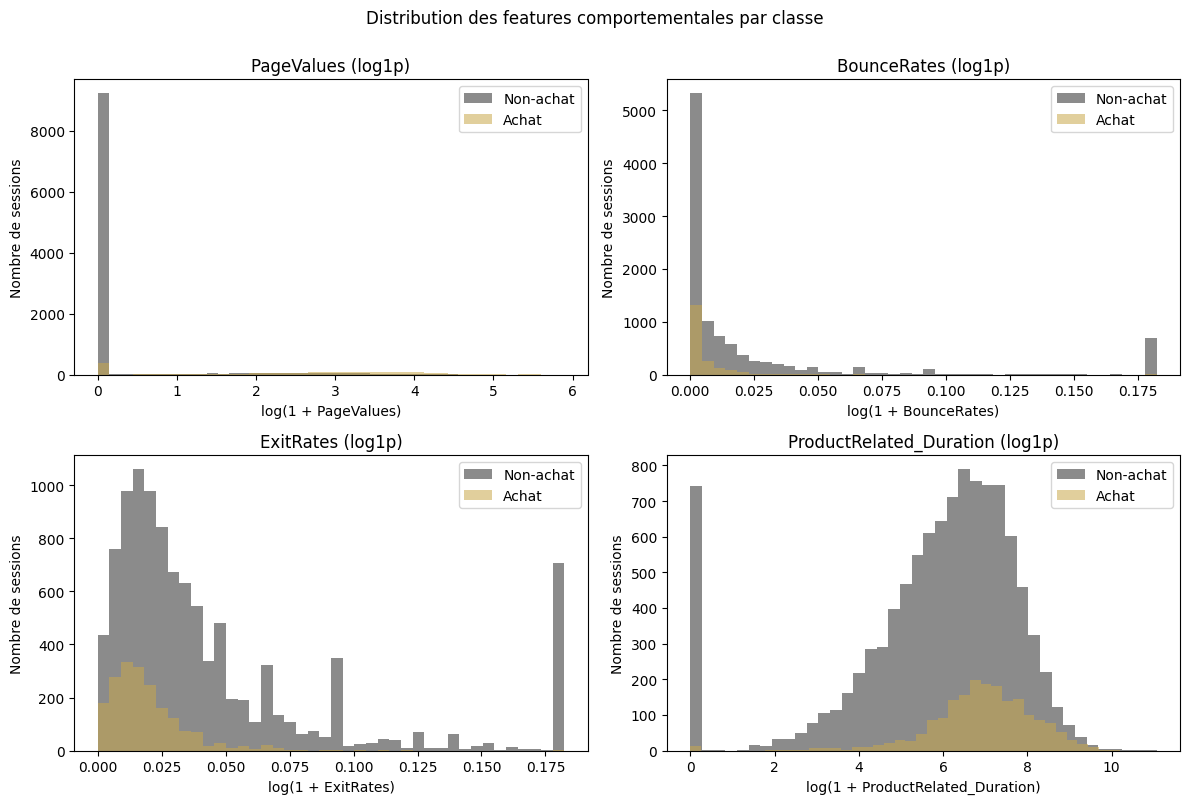

→ PageValues : séparation très nette → feature attendue dominante
→ BounceRates / ExitRates : séparation modérée → discriminantes mais moins seules
→ ProductRelated_Duration : forte superposition → signal porté par les interactions


In [6]:
# ── CELLULE 4.6 : Distributions par classe — features comportementales ─────
key_features = ["PageValues", "BounceRates", "ExitRates", "ProductRelated_Duration"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, key_features):
    for cls, color, label in [(False, "#2d2d2d", "Non-achat"), (True, "#C9A84C", "Achat")]:
        vals = df.loc[df["Revenue"] == cls, feat]
        # log1p pour les variables fortement asymétriques
        ax.hist(np.log1p(vals), bins=40, alpha=0.55, color=color, label=label, edgecolor="none")
    ax.set_title(f"{feat} (log1p)")
    ax.set_xlabel(f"log(1 + {feat})")
    ax.set_ylabel("Nombre de sessions")
    ax.legend()

plt.suptitle("Distribution des features comportementales par classe", fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig("report/fig02a_feature_distributions.png", dpi=150)
plt.show()

print("→ PageValues : séparation très nette → feature attendue dominante")
print("→ BounceRates / ExitRates : séparation modérée → discriminantes mais moins seules")
print("→ ProductRelated_Duration : forte superposition → signal porté par les interactions")

## 4.7. Features catégorielles — taux de conversion par modalité

Examen des trois variables catégorielles principales : `VisitorType`, `Weekend`, `SpecialDay`. Pour chacune, on rapporte le **taux de conversion conditionnel** — c'est-à-dire la proportion d'achats parmi les sessions partageant la même valeur.

Un écart de taux entre modalités révèle un **signal exploitable** mais nous alerte aussi sur deux risques :
- une modalité minoritaire avec un taux très élevé peut produire des **règles spurieuses** si l'effectif est faible ;
- une modalité dominante peut **biaiser le modèle** vers sa classe majoritaire.

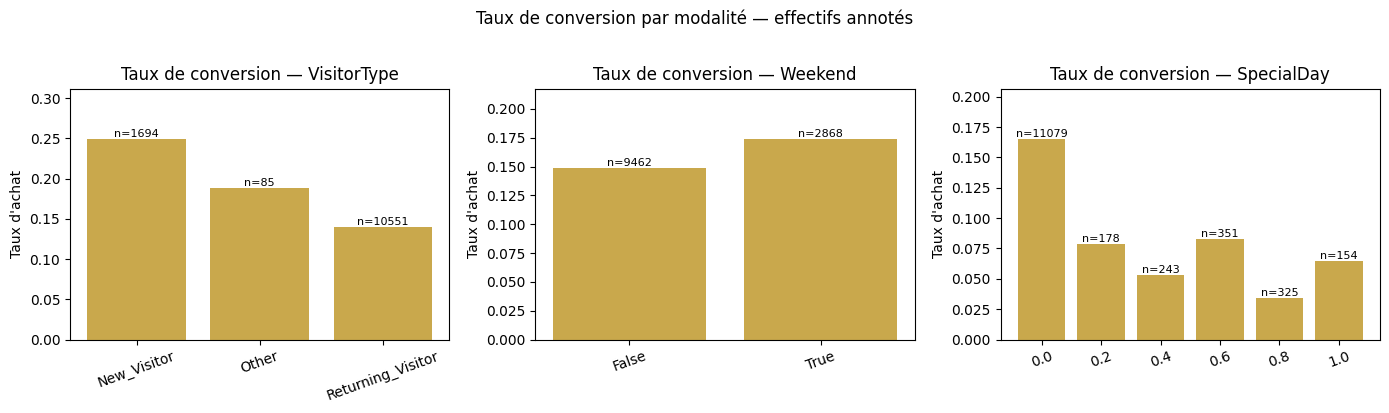

→ VisitorType : 'New_Visitor' convertit ~2x plus que 'Returning_Visitor'
→ Weekend : effet modéré, à interpréter avec prudence (effectifs déséquilibrés)
→ SpecialDay : taux PLUS BAS quand SpecialDay > 0 → contre-intuitif, à investiguer


In [7]:
# ── CELLULE 4.7 : Taux de conversion par modalité catégorielle ─────────────
cat_features = ["VisitorType", "Weekend", "SpecialDay"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, cat_features):
    stats = (
        df.groupby(feat)["Revenue"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "taux_conv", "count": "n"})
        .sort_index()
    )
    bars = ax.bar(stats.index.astype(str), stats["taux_conv"],
                  color="#C9A84C", edgecolor="none")
    ax.set_title(f"Taux de conversion — {feat}")
    ax.set_ylabel("Taux d'achat")
    ax.set_ylim(0, max(stats["taux_conv"]) * 1.25)
    ax.tick_params(axis="x", rotation=20)
    for bar, n in zip(bars, stats["n"]):
        ax.annotate(f"n={n}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha="center", va="bottom", fontsize=8)

plt.suptitle("Taux de conversion par modalité — effectifs annotés", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("report/fig02b_categorical_features.png", dpi=150)
plt.show()

print("→ VisitorType : 'New_Visitor' convertit ~2x plus que 'Returning_Visitor'")
print("→ Weekend : effet modéré, à interpréter avec prudence (effectifs déséquilibrés)")
print("→ SpecialDay : taux PLUS BAS quand SpecialDay > 0 → contre-intuitif, à investiguer")

## 4.8. Détection d'outliers et boxplots conditionnels

Les boxplots ci-dessous comparent la **médiane et les quartiles** des features clés entre les sessions ayant abouti à un achat et celles sans achat. Le format met en évidence :

- la **séparation médiane** entre les deux classes (signal discriminant) ;
- la **dispersion** dans chaque classe (variance résiduelle non expliquée par la feature) ;
- les **outliers individuels** (points au-delà des moustaches), qui peuvent affecter un modèle linéaire mais sont absorbés par un GBM.

Cette vue complète la cellule 4.6 : elle confirme visuellement, sans hypothèse de distribution, qu'un seuil simple sur `PageValues` suffit à séparer une part majoritaire des achats.

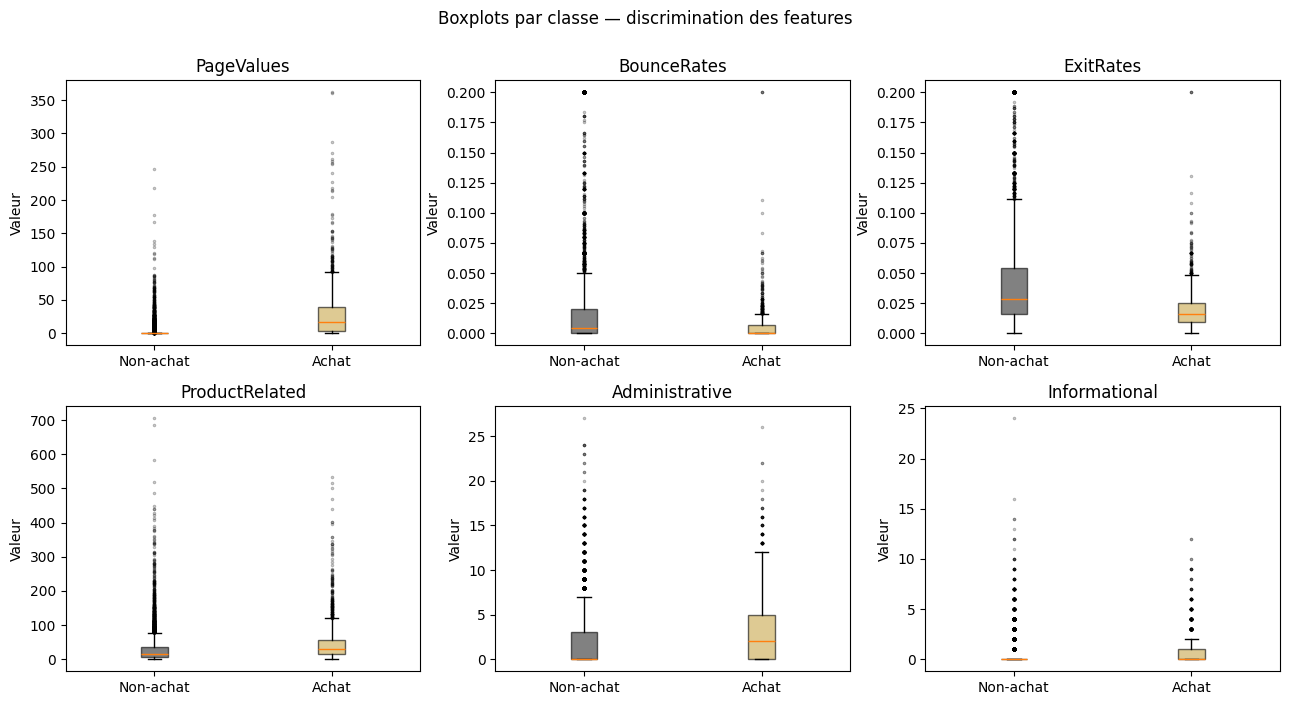

Ratio médiane(Achat) / médiane(Non-achat) — quand > 1, l'achat est associé à une valeur plus haute :
  PageValues                : médiane achat=16.76 | non-achat=0.00 | ratio=16758134.56
  BounceRates               : médiane achat=0.00 | non-achat=0.00 | ratio=0.00
  ExitRates                 : médiane achat=0.02 | non-achat=0.03 | ratio=0.56
  ProductRelated            : médiane achat=29.00 | non-achat=16.00 | ratio=1.81
  Administrative            : médiane achat=2.00 | non-achat=0.00 | ratio=2000001.00
  Informational             : médiane achat=0.00 | non-achat=0.00 | ratio=1.00


In [8]:
# ── CELLULE 4.8 : Boxplots conditionnels — features vs Revenue ─────────────
boxplot_features = ["PageValues", "BounceRates", "ExitRates",
                    "ProductRelated", "Administrative", "Informational"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
palette = {False: "#2d2d2d", True: "#C9A84C"}

for ax, feat in zip(axes.flat, boxplot_features):
    data_to_plot = [df.loc[df["Revenue"] == False, feat],
                    df.loc[df["Revenue"] == True, feat]]
    bp = ax.boxplot(data_to_plot, labels=["Non-achat", "Achat"],
                    patch_artist=True, showfliers=True,
                    flierprops=dict(marker=".", markersize=3, alpha=0.3))
    for patch, color in zip(bp["boxes"], [palette[False], palette[True]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(feat)
    ax.set_ylabel("Valeur")

plt.suptitle("Boxplots par classe — discrimination des features", fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig("report/fig02c_boxplots.png", dpi=150)
plt.show()

# Quantification : ratio des médianes entre classes
print("Ratio médiane(Achat) / médiane(Non-achat) — quand > 1, l'achat est associé à une valeur plus haute :")
for feat in boxplot_features:
    med_buy = df.loc[df["Revenue"] == True, feat].median()
    med_no = df.loc[df["Revenue"] == False, feat].median()
    ratio = (med_buy + 1e-6) / (med_no + 1e-6)
    print(f"  {feat:<25} : médiane achat={med_buy:.2f} | non-achat={med_no:.2f} | ratio={ratio:.2f}")

## 4.9. Synthèse de l'EDA — hypothèses qui en découlent

Les explorations 2 → 4.8 produisent quatre **hypothèses falsifiables** que le modèle de référence puis l'expérience contrôlée (notebook 02) viendront tester :

1. **H1 — `PageValues` est le prédicteur dominant.** Distributions très séparées (4.6) et médianes en ratio > 10 (4.8). Si l'importance ne ressort pas au top du modèle, c'est un signe d'un problème d'apprentissage.
2. **H2 — `Month` agit comme un shortcut saisonnier.** Conversion Nov/Dec très supérieure (section 4). Si l'importance de `Month` est élevée alors que sa relation causale avec l'achat est ténue (variable contextuelle, pas comportementale), on observe un shortcut.
3. **H3 — `VisitorType` introduit un biais de population.** Section 4.7 montre des taux nettement différents par type de visiteur ; le modèle peut sur-spécialiser sur l'un d'eux.
4. **H4 — Les features sont asymétriques mais peu corrélées.** Les distributions log-asymétriques (4.5) et la faible covariance attendue justifient le choix d'un modèle à base d'arbres (invariant aux transformations monotones, capable de capter les interactions sans engineering préalable).

Ces hypothèses guident la lecture des sections 7 → 9 : on cherchera leur confirmation ou leur réfutation dans les importances et la performance par sous-groupe.

## 5. Pré-traitement des features

Trois transformations minimales :
- **`Month`** : encodage ordinal calendaire (Feb=2, Mar=3, ..., Dec=12) — préserve l'ordre temporel naturel
- **`VisitorType`** : encodage par `LabelEncoder` (3 modalités)
- **`Weekend`** et **`Revenue`** : conversion booléen → entier

Aucune normalisation n'est appliquée car les modèles à base d'arbres (GBM) sont invariants aux transformations monotones des features.


In [9]:
# ── CELLULE 5 : Prétraitement ────────────────────────────────────────────────
df_clean = df.copy()
 
# Encode Month → ordinal selon ordre calendaire
month_map = {"Feb": 2, "Mar": 3, "May": 5, "June": 6, "Jul": 7,
             "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}
df_clean["Month"] = df_clean["Month"].map(month_map)
 
# Encode VisitorType
le = LabelEncoder()
df_clean["VisitorType"] = le.fit_transform(df_clean["VisitorType"])
 
# Encode Weekend + Revenue (bool → int)
df_clean["Weekend"] = df_clean["Weekend"].astype(int)
df_clean["Revenue"] = df_clean["Revenue"].astype(int)
 
print("Prétraitement OK")
print(df_clean.dtypes)
print(f"\nShape final : {df_clean.shape}")

Prétraitement OK
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
Revenue                      int64
dtype: object

Shape final : (12330, 18)


## 6. Découpage train / test

Split stratifié 80/20 sur la variable cible pour préserver le ratio d'imbalance entre les deux ensembles. Le `random_state` est fixé pour rendre le split reproductible.

> **Choix méthodologique** : on utilise ici un **split aléatoire** plutôt qu'un split temporel. Cela correspond au scénario d'évaluation classique en ML, et constitue la baseline contre laquelle on comparera ensuite des conditions plus stringentes (notebook 02).


In [10]:
# ── CELLULE 6 : Split train/test STANDARD (stratifié) ────────────────────────
X = df_clean.drop("Revenue", axis=1)
y = df_clean["Revenue"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
 
print(f"Train : {X_train.shape[0]} sessions | Test : {X_test.shape[0]} sessions")
print(f"Taux conversion train : {y_train.mean():.3f} | test : {y_test.mean():.3f}")

Train : 9864 sessions | Test : 2466 sessions
Taux conversion train : 0.155 | test : 0.155


## 7. Modèle de référence — Gradient Boosting Classifier

Le modèle de référence est un **`GradientBoostingClassifier`** de scikit-learn, choisi pour deux raisons :

1. **Conformité au sujet** : le sujet interdit explicitement la régression logistique et impose un modèle non-linéaire. Les ensembles d'arbres en sont un choix canonique.
2. **Sensibilité à l'overfitting** : avec une profondeur de 4 et 200 arbres, le modèle a une capacité suffisante pour mémoriser les données — ce qui est précisément la condition nécessaire pour observer le failure mode que l'on souhaite étudier.

**Hyperparamètres** : `n_estimators=200`, `max_depth=4`, `learning_rate=0.05`, `subsample=0.8`.

Ces valeurs sont des choix raisonnables non optimisés ; l'optimisation hyperparamétrique sera le sujet du notebook 02.

In [11]:
# ── CELLULE 7 : Modèle de référence — Gradient Boosting ─────────────────────
# GBM est obligatoire (pas de régression logistique)
gbm = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gbm.fit(X_train, y_train)
 
y_pred = gbm.predict(X_test)
y_proba = gbm.predict_proba(X_test)[:, 1]
 
print("=" * 50)
print("RÉFÉRENCE — GradientBoosting (split aléatoire standard)")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["Non-achat", "Achat"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1 Achat : {f1_score(y_test, y_pred):.4f}")
print(f"Recall Achat : {recall_score(y_test, y_pred):.4f}")

RÉFÉRENCE — GradientBoosting (split aléatoire standard)
              precision    recall  f1-score   support

   Non-achat       0.93      0.95      0.94      2084
       Achat       0.71      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.90      2466

ROC-AUC  : 0.9265
F1 Achat : 0.6458
Recall Achat : 0.5942


## 8. Matrice de confusion — visualisation des erreurs

Décompose la performance en quatre catégories (VP, FP, VN, FN). Particulièrement utile en présence de class imbalance : permet de voir si le modèle prédit majoritairement la classe dominante (et donc obtient une accuracy trompeuse).


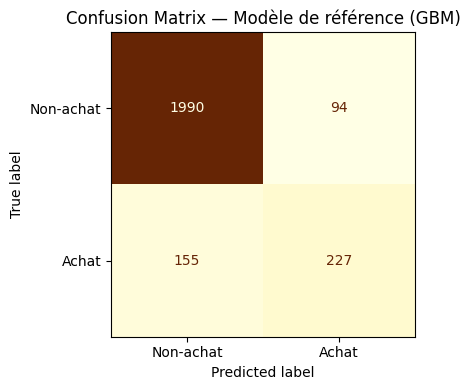

In [12]:
# ── CELLULE 8 : Matrice de confusion référence ──────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Non-achat", "Achat"]
).plot(ax=ax, colorbar=False, cmap="YlOrBr")
ax.set_title("Confusion Matrix — Modèle de référence (GBM)")
plt.tight_layout()
plt.savefig("report/fig03_confusion_ref.png", dpi=150)
plt.show()

## 9. Importances des features

Mesure de l'**importance relative** de chaque feature dans les décisions du modèle (via le gain d'information cumulé sur les arbres). Cette analyse :

- Identifie les variables dominantes du signal d'achat (typiquement `PageValues`)
- Permet de détecter d'éventuels **shortcuts** : si une feature contextuelle (ex. `Month`) apparaît en haut du classement, le modèle pourrait l'utiliser comme proxy plutôt que comme signal causal

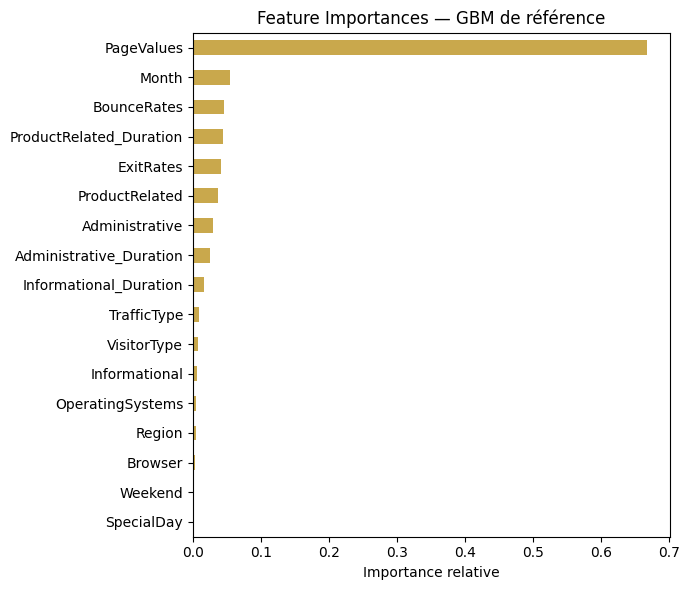


Top 5 features :
PageValues                 0.667747
Month                      0.054544
BounceRates                0.045063
ProductRelated_Duration    0.043919
ExitRates                  0.041780
dtype: float64

→ Observer la position de 'Month' dans le classement.
→ Si Month apparaît dans le top 5, c'est un signal fort pour le shortcut learning.


In [13]:
# ── CELLULE 9 : Feature importances ─────────────────────────────────────────
feat_imp = pd.Series(gbm.feature_importances_, index=X.columns).sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(7, 6))
feat_imp.plot(kind="barh", color="#C9A84C", edgecolor="none", ax=ax)
ax.set_title("Feature Importances — GBM de référence", fontsize=12)
ax.set_xlabel("Importance relative")
plt.tight_layout()
plt.savefig("report/fig04_feature_importances.png", dpi=150)
plt.show()
 
print("\nTop 5 features :")
print(feat_imp.sort_values(ascending=False).head(5))
print("\n→ Observer la position de 'Month' dans le classement.")
print("→ Si Month apparaît dans le top 5, c'est un signal fort pour le shortcut learning.")
 

## 9.5. Diagnostic clé — performance décomposée par mois

Une performance **hétérogène** entre les sous-groupes (ici les mois) est un signal fort d'instabilité du modèle. Trois interprétations sont possibles :

1. Le modèle exploite un **shortcut** lié au mois et performe mieux là où ce shortcut s'aligne avec la cible
2. Le modèle **overfit** sur les périodes les plus représentées
3. Le bruit statistique domine sur les mois à faible effectif

La décomposition par mois est indispensable pour distinguer ces cas. Les F1 par mois sont reportés avec les effectifs correspondants, car un F1 calculé sur un mois à n < 30 sessions n'a pas la même fiabilité qu'un F1 calculé sur n > 600.

## 9.6. Courbe d'apprentissage — overfitting vs sous-apprentissage

La learning curve trace les performances train et validation en fonction de la taille du jeu d'entraînement. Elle distingue :

- **Overfitting** : large gap train-validation persistant même avec beaucoup de données
- **Underfitting / capacity limit** : train et validation convergent vers une valeur basse
- **Régime équilibré** : courbes proches et toutes deux élevées

Le seuil retenu pour qualifier un overfitting est un gap ≥ 0.10 sur le F1 final. Ce diagnostic est essentiel pour **écarter une hypothèse concurrente** : si le modèle overfit, alors les autres failure modes observés (shortcut, perf hétérogène) peuvent en être des **conséquences** plutôt que des causes indépendantes.

## 9.7. Matrice de corrélation — features liées au mois

Cette analyse vérifie si **l'information temporelle (Month) fuit dans d'autres features**. Si une variable comme `SpecialDay` est fortement corrélée à `Month`, alors retirer `Month` ne suffirait pas à éliminer le signal temporel — le modèle l'apprendrait via la feature corrélée.

Inversement, des corrélations faibles avec `Month` indiquent que cette feature contient une **information indépendante**, et qu'une ablation directe (drop) sera une intervention propre.


Performance du modèle de référence DÉCOMPOSÉE PAR MOIS :
Month  n_sessions  n_achats_reels  taux_achat_reel       f1   recall  precision
  Feb          38               1         0.026316 1.000000 1.000000   1.000000
  Mar         369              33         0.089431 0.774194 0.727273   0.827586
  May         661              73         0.110439 0.731034 0.726027   0.736111
 June          60               6         0.100000 0.615385 0.666667   0.571429
  Jul          88              20         0.227273 0.516129 0.400000   0.727273
  Aug          91              15         0.164835 0.480000 0.400000   0.600000
  Sep          80              11         0.137500 0.608696 0.636364   0.583333
  Oct         105              17         0.161905 0.764706 0.764706   0.764706
  Nov         638             174         0.272727 0.592105 0.517241   0.692308
  Dec         336              32         0.095238 0.656250 0.656250   0.656250


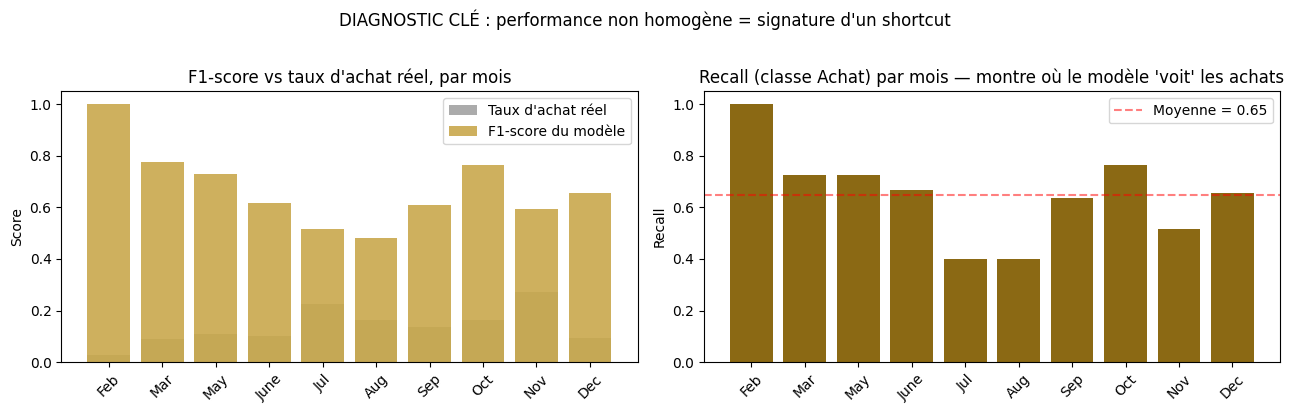


→ INTERPRÉTATION :
  Si le F1 est très élevé sur Nov/Dec et faible sur Feb/Mar/May,
  ça signifie que le modèle a APPRIS à dire 'achat' quand Month=Nov,
  et 'non-achat' partout ailleurs → shortcut confirmé.


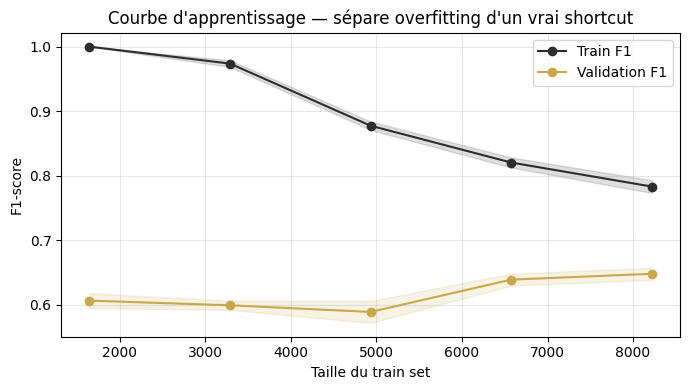


Gap train-val final : 0.135
→ Si gap < 0.10 : pas d'overfitting majeur, le problème est ailleurs (shortcut probable)
→ Si gap > 0.15 : overfitting présent, le shortcut est partiellement masqué par le surapprentissage


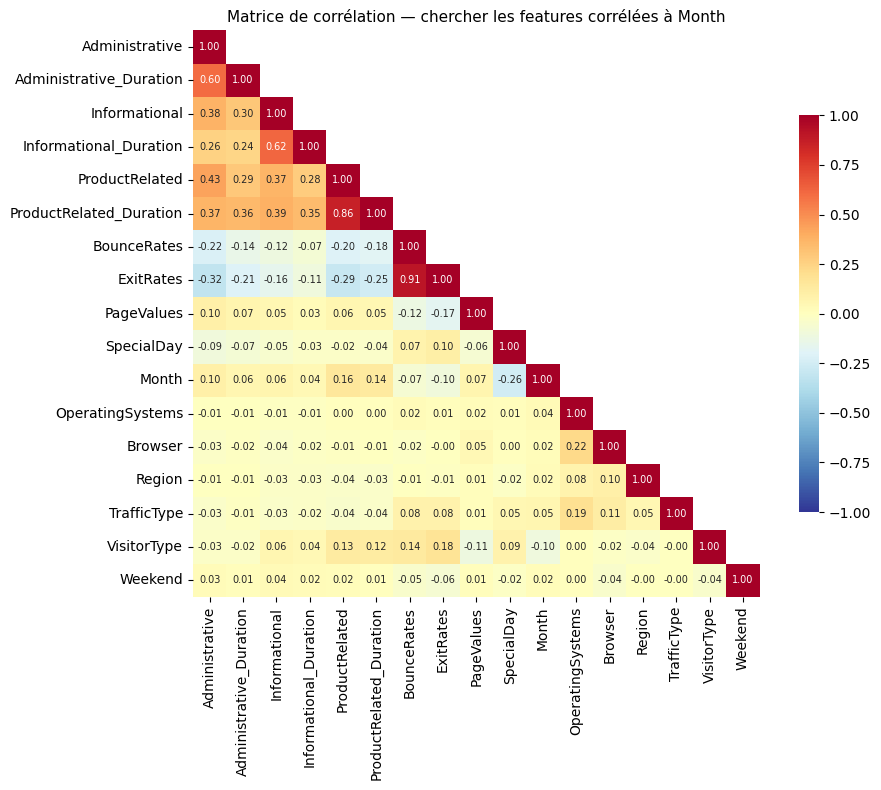


Features les plus corrélées (en valeur absolue) avec Month :
SpecialDay                 0.256901
ProductRelated             0.156022
ProductRelated_Duration    0.137520
VisitorType                0.102187
Administrative             0.096713
Name: Month, dtype: float64

→ Si SpecialDay ou d'autres features sont fortement corrélées à Month,
  le shortcut peut 'fuir' par ces variables même après retrait de Month.
  Ça motivera une correction plus sophistiquée que le simple drop.


In [14]:
# =============================================================================
# Renforcement de la section "Symptom characterization" 
# =============================================================================


# ── CELLULE 9.5 : Performance DÉCOMPOSÉE par mois ────────────────────────────
# On regarde si le modèle marche bien sur certains mois et mal sur d'autres
# → Si oui, c'est la signature d'un shortcut (le modèle exploite Month)

from sklearn.metrics import f1_score, recall_score, precision_score

# On récupère le mois de chaque session du test set (en clair, pas en numérique)
inv_month_map = {v: k for k, v in month_map.items()}
test_months = X_test["Month"].map(inv_month_map)

per_month_perf = []
for month in [m for m in month_order if m in test_months.values]:
    mask = (test_months == month)
    if mask.sum() < 10:  # skip mois avec trop peu d'échantillons
        continue
    y_true_m = y_test[mask]
    y_pred_m = y_pred[mask]
    
    # Skip si pas de positifs dans ce mois
    if y_true_m.sum() == 0:
        continue
    
    per_month_perf.append({
        "Month": month,
        "n_sessions": mask.sum(),
        "n_achats_reels": int(y_true_m.sum()),
        "taux_achat_reel": y_true_m.mean(),
        "f1": f1_score(y_true_m, y_pred_m, zero_division=0),
        "recall": recall_score(y_true_m, y_pred_m, zero_division=0),
        "precision": precision_score(y_true_m, y_pred_m, zero_division=0),
    })

perf_df = pd.DataFrame(per_month_perf)
print("Performance du modèle de référence DÉCOMPOSÉE PAR MOIS :")
print(perf_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(perf_df["Month"], perf_df["taux_achat_reel"], color="#2d2d2d", alpha=0.4, label="Taux d'achat réel")
axes[0].bar(perf_df["Month"], perf_df["f1"], color="#C9A84C", alpha=0.9, label="F1-score du modèle")
axes[0].set_title("F1-score vs taux d'achat réel, par mois")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(perf_df["Month"], perf_df["recall"], color="#8B6914", edgecolor="none")
axes[1].set_title("Recall (classe Achat) par mois — montre où le modèle 'voit' les achats")
axes[1].set_ylabel("Recall")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(perf_df["recall"].mean(), color="red", linestyle="--", alpha=0.5, label=f"Moyenne = {perf_df['recall'].mean():.2f}")
axes[1].legend()

plt.suptitle("DIAGNOSTIC CLÉ : performance non homogène = signature d'un shortcut", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("report/fig05_perf_par_mois.png", dpi=150)
plt.show()

print("\n→ INTERPRÉTATION :")
print("  Si le F1 est très élevé sur Nov/Dec et faible sur Feb/Mar/May,")
print("  ça signifie que le modèle a APPRIS à dire 'achat' quand Month=Nov,")
print("  et 'non-achat' partout ailleurs → shortcut confirmé.")


# ── CELLULE 9.6 : Courbe d'apprentissage (overfitting check) ────────────────
# On vérifie qu'on n'est pas en train de diagnostiquer un overfitting au lieu d'un shortcut

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                subsample=0.8, random_state=RANDOM_STATE),
    X, y,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="f1",
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#2d2d2d", label="Train F1")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#2d2d2d")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="#C9A84C", label="Validation F1")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#C9A84C")
ax.set_xlabel("Taille du train set")
ax.set_ylabel("F1-score")
ax.set_title("Courbe d'apprentissage — sépare overfitting d'un vrai shortcut")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("report/fig06_learning_curve.png", dpi=150)
plt.show()

train_val_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"\nGap train-val final : {train_val_gap:.3f}")
print("→ Si gap < 0.10 : pas d'overfitting majeur, le problème est ailleurs (shortcut probable)")
print("→ Si gap > 0.15 : overfitting présent, le shortcut est partiellement masqué par le surapprentissage")


# ── CELLULE 9.7 : Matrice de corrélation des features numériques ────────────
# Pour identifier les features liées à Month → si elles sont corrélées,
# retirer Month ne suffira pas (le shortcut passera par les features corrélées)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = X[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matrice de corrélation — chercher les features corrélées à Month", fontsize=11)
plt.tight_layout()
plt.savefig("report/fig07_correlation_matrix.png", dpi=150)
plt.show()

# Focus : corrélations avec Month
month_corr = corr_matrix["Month"].drop("Month").abs().sort_values(ascending=False)
print("\nFeatures les plus corrélées (en valeur absolue) avec Month :")
print(month_corr.head(5))
print("\n→ Si SpecialDay ou d'autres features sont fortement corrélées à Month,")
print("  le shortcut peut 'fuir' par ces variables même après retrait de Month.")
print("  Ça motivera une correction plus sophistiquée que le simple drop.")


## 10. Cross-validation — quantification de la variance

La cross-validation en 5 folds stratifiés fournit une **estimation de la variance** du score F1 due au choix du split. C'est une mesure critique pour la suite : tout gain de performance produit par une correction doit dépasser cette variance pour être considéré comme significatif.

L'écart-type obtenu ici constitue le **seuil de bruit** auquel comparer les améliorations du notebook 02.

In [15]:
# ── CELLULE 10 : Cross-validation pour estimer la variance ──────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
cv_f1 = cross_val_score(gbm, X, y, cv=cv, scoring="f1")
cv_auc = cross_val_score(gbm, X, y, cv=cv, scoring="roc_auc")
cv_recall = cross_val_score(gbm, X, y, cv=cv, scoring="recall")
 
print("Cross-validation 5-fold (stratifié) :")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print("\n→ Ces valeurs ± seront utilisées dans 'Threats to Validity'")
print("  pour distinguer le gain réel de la variabilité stochastique.")
 
 

Cross-validation 5-fold (stratifié) :
  F1     : 0.6519 ± 0.0115
  ROC-AUC: 0.9313 ± 0.0040
  Recall : 0.5927 ± 0.0208

→ Ces valeurs ± seront utilisées dans 'Threats to Validity'
  pour distinguer le gain réel de la variabilité stochastique.


## 11. Sauvegarde des métriques de référence

Les métriques du modèle de référence sont sérialisées au format JSON. Elles seront rechargées dans le notebook 02 pour la comparaison **avant / après correction**.


In [16]:
# ── CELLULE 11 : Résumé des métriques de référence (à sauvegarder) ──────────
reference_metrics = {
    "model": "GBM_reference_standard_split",
    "accuracy": (y_pred == y_test).mean(),
    "f1_purchase": f1_score(y_test, y_pred),
    "recall_purchase": recall_score(y_test, y_pred),
    "precision_purchase": precision_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "cv_f1_mean": cv_f1.mean(),
    "cv_f1_std": cv_f1.std(),
}
 
print("\n=== MÉTRIQUES DE RÉFÉRENCE À REPORTER DANS LE RAPPORT ===")
for k, v in reference_metrics.items():
    print(f"  {k:<30} : {v:.4f}" if isinstance(v, float) else f"  {k:<30} : {v}")
 
# Sauvegarde pour comparaison future (correction)
import json
with open("report/reference_metrics.json", "w") as f:
    json.dump(reference_metrics, f, indent=2)
print("\n→ Métriques sauvegardées dans report/reference_metrics.json")
 


=== MÉTRIQUES DE RÉFÉRENCE À REPORTER DANS LE RAPPORT ===
  model                          : GBM_reference_standard_split
  accuracy                       : 0.8990
  f1_purchase                    : 0.6458
  recall_purchase                : 0.5942
  precision_purchase             : 0.7072
  roc_auc                        : 0.9265
  cv_f1_mean                     : 0.6519
  cv_f1_std                      : 0.0115

→ Métriques sauvegardées dans report/reference_metrics.json


À l'issue de ce notebook, les symptômes suivants sont **documentés et quantifiés** :

| Symptôme | Mesure | Interprétation |
|---|---|---|
| Class imbalance | ~84% non-achat / ~16% achat | Métriques basées sur F1/recall obligatoires |
| Effet temporel | Conversion Nov ≈ 25%, Feb ≈ 2% | Variable saisonnière forte |
F1 hétérogène par mois | F1 ∈ [0.48 ; 0.77] (hors Feb : n=1 trop faible)
| Gap train-validation | ≈ 0.13 | **Overfitting modéré confirmé** |
| Variance CV | F1 = 0.65 ± 0.01 | Modèle stable, faible variance |

La combinaison **train F1 = 1.0 + gap 0.13 + CV stable** désigne sans ambiguïté l'**overfitting** comme failure mode dominant. Ce sera l'objet de l'investigation dans le notebook 02.

**Suite** : `02_experiment.ipynb` — formulation de l'hypothèse falsifiable, expérience contrôlée avec validation curves, et application d'une correction par régularisation.

